Connecting to HF2LI...
Connected to dev376

Initializing HF2LI...
  Initializing signal inputs...
    Signal inputs initialized.
  Initializing signal outputs...
    Signal outputs initialized.
  Initializing oscillators...
    Oscillators initialized.
  Initializing demodulators...
    Demodulators initialized.
  Initializing PLLs...
    PLLs initialized.
  Initializing PID controllers...
    PID controllers initialized.
  Initializing scope...
    Scope initialized.
  Initializing auxiliary outputs...
    Auxiliary outputs initialized.

Initialization complete.

Configuring output 0...
  Output configured.
Configuring input 0...
  Input configured.
Configuring input 1...
  Input configured.
Configuring demodulator 0...
  Demodulator configured.
Configuring demodulator 1...
  Demodulator configured.

Experiment folder created
Data\2026-08-18_17-18-23

Settings saved.
Data\2026-08-18_17-18-23\settings.txt


Starting frequency sweep
1/200: 700.00 Hz
21/200: 750.25 Hz
41/200: 800.50 Hz
6

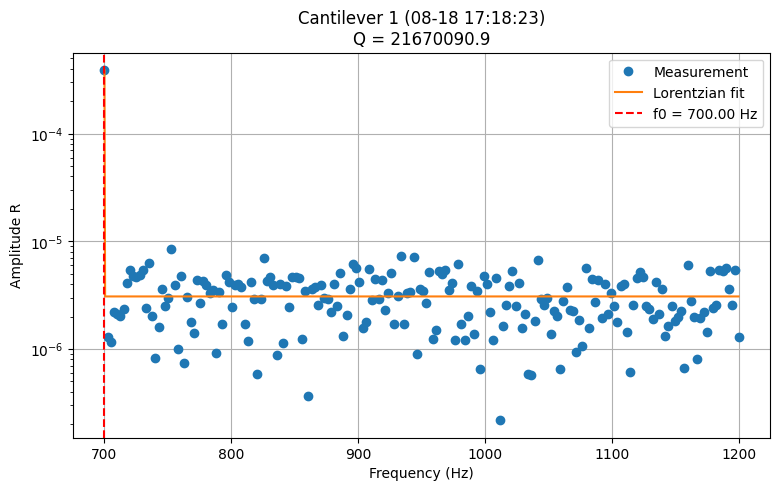

CHECKPOINT 6: PLOT 0 DONE

Starting plot demod 1


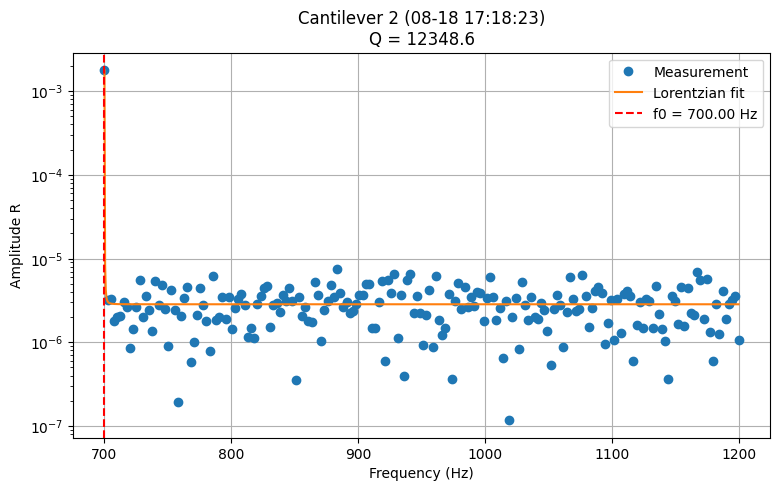

CHECKPOINT 7: PLOT 1 DONE
707.1334389934158 , 2.0262261511373763e-06
711.9464054113986 , 2.044691437184261e-06
715.864894078744 , 2.883950575663821e-06
727.0019434461786 , 4.799236126216986e-06
728.0579647118954 , 4.941634579845188e-06
732.0411794582354 , 3.1589022269486165e-06
733.2344200830591 , 3.2967863634959845e-06
738.0229941759765 , 1.8835769110248946e-06
747.7441669676859 , 2.484640192610855e-06
761.5832148527394 , 2.736461206093903e-06
766.7570211630718 , 2.3189924439097553e-06
774.2563051199742 , 3.4309825498208494e-06
776.7655291898218 , 3.564968990278347e-06
784.1367438286663 , 3.416629714811016e-06
788.9354154865206 , 1.909342025036083e-06
791.600775112333 , 2.639409309445134e-06
793.886331533303 , 2.8660084676561444e-06
807.9316967750152 , 3.7940519635164865e-06
813.0018962315829 , 1.19380606958367e-06
819.1855226788986 , 1.8879530412411657e-06
823.5959020852955 , 3.6894004750828783e-06
827.8066606663472 , 4.613103640783575e-06
828.429095738777 , 4.287718321013208e-06
834

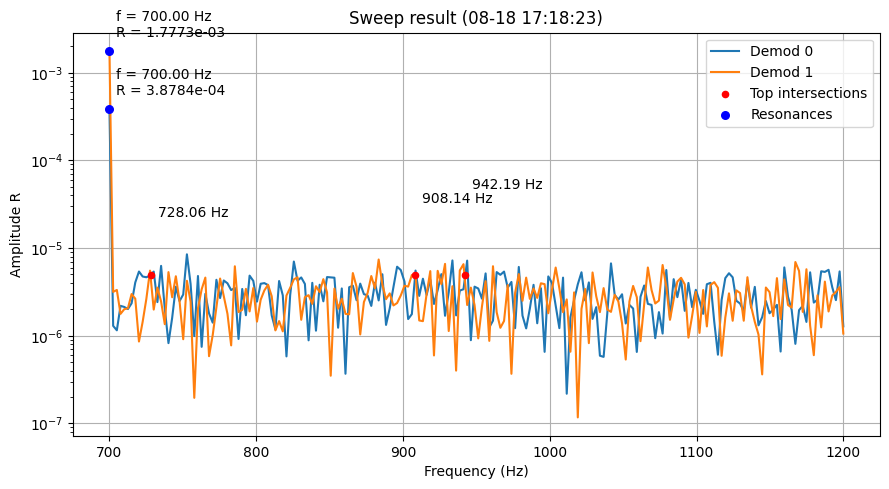

CHECKPOINT 8: SWEEP PLOT DONE. ---  08-18 17:18:23


In [ ]:
import os # enable the file system operation //12AUG YZ
# import json # not necesssary to import json here since the dataio.py imports it //18AUG YZ
from datetime import datetime # added for enabling timestamp in the plot title //07AUG YZ //12AUG YZ

from instrument.hf2li import HF2LI
from instrument import config 

from measurements.sweeper import FrequencySweeper
from measurements.experiment import ExperimentRunner

from utils.dataio import save_sweep_to_folder

from analysis.resonance import fit_resonance


# this cell creates a folder which has the name  of the current date and time. 
# it contains two files: settings.txt and sweep.npz. the settings.txt file contains the settings of the lock-in amplifier, 
# and the sweep.npz file contains the data of the frequency sweep. //06AUG YZ
# Create HF2LI driver, no communication to or control over the instrument yet
lockin = HF2LI(
    device_id=config.DEVICE_ID,
    host=config.SERVER_HOST,
    hf2=config.HF2
)

# connect to instrument.
lockin.connect()

# Initialize the instrument to a known safe state, and every experiment should start from this state.
# - outputs disabled
# - demodulators disabled
# - oscillators reset
# - feedback systems disabled
lockin.initialize()

# Configure experiment

# Signal output
lockin.configure_output(
    channel=config.OUTPUT_CHANNEL,
    amplitude=config.AMPLITUDE,
    offset=config.OFFSET
)

# Signal inputs
lockin.configure_input(
    channel=0,
    input_range=config.INPUT_RANGE_1
)

lockin.configure_input(
    channel=1,
    input_range=config.INPUT_RANGE_2
)

# Demodulators
lockin.configure_demod(
    demod=config.DEMOD_1,
    adc=config.ADC_1,
    oscillator=config.OSCILLATOR_1,
    rate=config.DEMOD_RATE_1
)


lockin.configure_demod(
    demod=config.DEMOD_2,
    adc=config.ADC_2,
    oscillator=config.OSCILLATOR_2,
    rate=config.DEMOD_RATE_2
)

# =========================================================
# Create experiment folder#
# Everything related to this experiment will be saved here:#
# settings.txt
# sweep.npz
# fit results
# interactive measurements#
# =========================================================

# =========================================================
# Experiment metadata#
# General information about this experiment.
# The angle is added for later complex-plane analysis.
# =========================================================

experiment_angle = float(
    input(
        "Experimental angle (deg): "
    )
)
# ask for input the experimental angle in degrees for sweeping  // 13AUG YZ

metadata = {

    "device": config.DEVICE_ID,

    "experiment":
        "Two cantilever resonance measurement",

    "experiment_angle":
        experiment_angle

}


experiment = ExperimentRunner(
    recorder=None,
    settings=config.settings,
    metadata=metadata
)

# =========================================================
# Frequency sweep
# The oscillator frequency is swept.
# Both demodulators are recorded.
# =========================================================

timestamp = datetime.now().strftime("%m-%d %H:%M:%S") # implemenet the timestamp in the plot title //07AUG YZ // move timestamp to the beginning of sweep 12AUG YZ

sweeper = FrequencySweeper(
    lockin
)

data = sweeper.sweep(
    start_frequency=config.F_START,
    stop_frequency=config.F_STOP,
    points=config.POINTS,
    demods=(0,1),
    live_plot=False # change to false to disable live plotting //10AUG YZ
)

lockin.disable_excitation()

print()
print("Sweep finished.")
print(data.keys())
print()

# =========================================================
# Save sweep
# The raw sweep is stored inside the experiment folder.
# =========================================================

sweep_file = save_sweep_to_folder(
    data,
    experiment.run_folder
)

print("Experiment folder:")
print(experiment.run_folder)

print("sweepfile")
print(sweep_file)

# the sweep data is saved in the experiment folder, the sweep.npz file contains the data of the frequency sweep. //07AUG YZ

# move resonance resulting and plotting here, begins //11AUG YZ
## =========================================================
# Load saved sweep data
#
# We analyze the saved raw measurement.
# The instrument data itself is not modified.
# =========================================================

# this cell's execution would ask for three times of input:
    # 1st describes the experiment, 2nd is the folder name of the experiment, 3rd is the confirmation of start //07AUG YZ
#in the folder of the experiment, settings andsweep.npz are generated when the first cell is excuted. //07AUG YZ

# the cell picks up the CH1 resonance frequency to continue the experiment as the first step. //07AUG YZ

import numpy as np

print()
print("CHECKPOINT 1: Loading sweep")
loaded = np.load(
    sweep_file,
    allow_pickle=True
)

print("Loaded file:")
print(sweep_file)

print()
print("Available channels:")
print(loaded.files)


# =========================================================
# Convert numpy archive into dictionary
# =========================================================

data_loaded = {
    key: loaded[key]
    for key in loaded.files
}

print()
print("CHECKPOINT 2: Sweep converted to dictionary")

# =========================================================
# Extract frequency and amplitudes
#
# Demod 0 -> first cantilever
# Demod 1 -> second cantilever
# =========================================================

from analysis.parser import (
    get_frequency,
    get_channel
)

frequency = get_frequency(data_loaded)

amplitude_0 = get_channel(
    data_loaded,
    demod=0,
    quantity="r"
)

amplitude_1 = get_channel(
    data_loaded,
    demod=1,
    quantity="r"
)

print()
print("CHECKPOINT 3: Channels extracted")
print(
    "Frequency points:",
    len(frequency)
)
print(
    "Demod 0:",
    len(amplitude_0)
)
print(
    "Demod 1:",
    len(amplitude_1)
)

# Resonance fitting

from analysis.resonance import fit_resonance

print()
# cantilever 1/channel 1 resonance fit
print("Starting fit demod 0")
fit_0 = fit_resonance(
    frequency,
    amplitude_0
)# resonance frequency and amplitude
print()
print("Demod 0")
print(fit_0)
print("CHECKPOINT 4: FIT 0 DONE")

# fit_0 = fit_resonance get a output with structure as: //13AUG YZ
    # fit_0["f0"]          # resonance frequency
    # fit_0["gamma"]       # linewidth
    # fit_0["Q"]           # quality factor
    # fit_0["parameters"]  # fitting parameters
    # fit_0["covariance"]  # fitting uncertainty information
# there is no amplitude included in it //13AUG YZ


print()
# cantilever 2/channel 2 resonance fit
print("Starting fit demod 1")
fit_1 = fit_resonance(
    frequency,
    amplitude_1
)# resonance frequency and amplitude
print()
print("Demod 1")
print(fit_1)
print("CHECKPOINT 5: FIT 1 DONE")


# Plot resonance fits

from analysis.plotting import plot_resonance_fit
from analysis.plotting import plot_sweep

print()
print()

print(experiment.run_folder)

print("plot resonance")

plot_resonance_fit( # save the plot of the resonance has been added//15AUG YZ
    frequency,
    amplitude_0,
    fit_0,
    # title="Cantilever 1"
    save_path = os.path.join(
        experiment.run_folder,
        "resonance_cantilever_1.png"
    ),
    title=f"Cantilever 1 ({timestamp})"
)
print("CHECKPOINT 6: PLOT 0 DONE")

print()
print("Starting plot demod 1")
plot_resonance_fit(
    frequency,
    amplitude_1,
    fit_1,
    # title="Cantilever 2"
    save_path = os.path.join(
        experiment.run_folder,
        "resonance_cantilever_2.png"
    ),
    title=f"Cantilever 2 ({timestamp})"

)
print("CHECKPOINT 7: PLOT 1 DONE")

plot_sweep(
    frequency,
    amplitude_0,
    amplitude_1,
    fit_0,
    fit_1,
    timestamp=timestamp,
    save_path=os.path.join(
        experiment.run_folder,
        "sweep.png"
    )
)

# move resonance resulting and plotting here, ends //11AUG YZ

# plot the sweep result, begins //12AUG YZ
# move plotting of sweep to plotting.py begins //15AUG YZ
# move plotting of sweep to plotting.py ends //15AUG YZ
# plot the sweep result, ends //12AUG YZ
print("CHECKPOINT 8: SWEEP PLOT DONE.")
from utils.dataio import save_fit

print()

print("Saving fit results")

save_fit(
    fit_0,
    experiment.run_folder,
    filename="fit_demod0.json"
)

print("CHECKPOINT 8: FIT 0 SAVED")

save_fit(
    fit_1,
    experiment.run_folder,
    filename="fit_demod1.json"
)

print("CHECKPOINT 9: FIT 1 SAVED. -- ", timestamp)


In [3]:
# move to 1st cell to show resonance plotting, begins //11AUG YZ
# move to 1st cell to show resonance plotting, ends//11AUG YZ

# f0 = fit_0["f0"] commented to run a specified test with two cantilevers under 900 Hz //12AUG
# f0 = 915
# set the CH1 resonance frequency as the oscillator frequency for the next stps //07AUG YZ

import os

while True: # initial input for the experiment frequency //15AUG YZ

    f0_input = input(
        "Experiment frequency, q = quit: "
    ).strip()

    if f0_input.lower() == "q":
        print("Experiment finished.")
        raise SystemExit

    try:
        f0 = int(f0_input) # only accept an integer for input//15AUG YZ
        break

    except ValueError:
        print("Invalid input. Please enter an integer or q.")


frequency_file = os.path.join( #
    experiment.run_folder,
    f"{f0}_Hz.txt" # entered frequency will be the filename //15AUG YZ
)

while True:

    distance_input = input(
        "Distance, q = quit: "
    ).strip()

    if distance_input.lower() == "q":
        print("Experiment finished.")
        raise SystemExit

    try:
        distance = float(distance_input)
        break

    except ValueError:
        print("Invalid input. Please enter a number or q.")

with open(frequency_file, "w") as file: # write the distance value into file created //15AUG YZ
    file.write(f"{distance}\n")


# fit result saving is moved to the 1st cell, begins //18AUG YZ
# fit result saving is moved to the 1st cell, ends //18AUG YZ

print()
print("Setting HF2LI frequency") #experiment frequency defined by user input //16AUG YZ


lockin.set_frequency(f0)
lockin.disable_excitation()

print("CHECKPOINT 10: FREQUENCY SET")

# =========================================================
# Prepare interactive measurement
# =========================================================

from measurements.recorder import HF2LIRecorder

print()

print("Creating recorder")

recorder = HF2LIRecorder(
    lockin,
    demods=(0,1)
)

print("CHECKPOINT 11: RECORDER CREATED")

# Attach recorder to existing experiment

experiment.recorder = recorder
print("CHECKPOINT 12: RECORDER ATTACHED")

# =========================================================
# Start interactive experiment
# =========================================================


print()
print("STARTING INTERACTIVE EXPERIMENT")

experiment.run(
    duration=2.0
)


Saving fit results

Fit saved:
Data\2026-08-17_13-02-28\fit_demod0.json
CHECKPOINT 8: FIT 0 SAVED

Fit saved:
Data\2026-08-17_13-02-28\fit_demod1.json
CHECKPOINT 9: FIT 1 SAVED

Setting HF2LI frequency
Excitation disabled
CHECKPOINT 10: FREQUENCY SET

Creating recorder
CHECKPOINT 11: RECORDER CREATED
CHECKPOINT 12: RECORDER ATTACHED

STARTING INTERACTIVE EXPERIMENT
Excitation disabled

--------------------------------
Measurement 1

Recording...
Starting measurement
Excitation enabled
Streaming: ['/dev376/demods/0/sample', '/dev376/demods/1/sample']
Demod 0 points: 1800
Demod 1 points: 1784
Synchronizing to 1784 points
Points recorded: 1784
Excitation disabled
Excitation disabled
Recording finished.
DEBUG experiment_angle = 45.0
Saved: Data\2026-08-17_13-02-28\001_angle_45.npy
Excitation disabled

--------------------------------
Measurement 2

Recording...
Starting measurement
Excitation enabled
Streaming: ['/dev376/demods/0/sample', '/dev376/demods/1/sample']
Demod 0 points: 1803
De

Reading:
Data\2026-08-16_11-11-11
Loaded: 001_angle_0.npy
{'time': array([        0,    233472,    466944, ..., 419782656, 420016128,
       420249600], shape=(1801,), dtype=uint64), 'x_0': array([-0.06679655, -0.06838327, -0.06993554, ..., -0.10184655,
       -0.10184333, -0.10183871], shape=(1801,)), 'y_0': array([-0.07014088, -0.07188939, -0.0735839 , ..., -0.11415592,
       -0.11412763, -0.11409915], shape=(1801,)), 'r_0': array([0.09685826, 0.09921872, 0.10151636, ..., 0.15298462, 0.15296137,
       0.15293704], shape=(1801,)), 'phase_0': array([-133.60098331, -133.56818775, -133.54381548, ..., -131.73840375,
       -131.74455911, -131.75037208], shape=(1801,)), 'x_1': array([6.59383346e-05, 7.45877094e-05, 8.32994705e-05, ...,
       6.07694594e-04, 6.18406865e-04, 6.30398809e-04], shape=(1801,)), 'y_1': array([-2.84102912e-04, -2.83246881e-04, -2.82848972e-04, ...,
       -1.35949923e-05, -1.49608710e-05, -1.67226121e-05], shape=(1801,)), 'r_1': array([0.00029165, 0.0002929 , 0

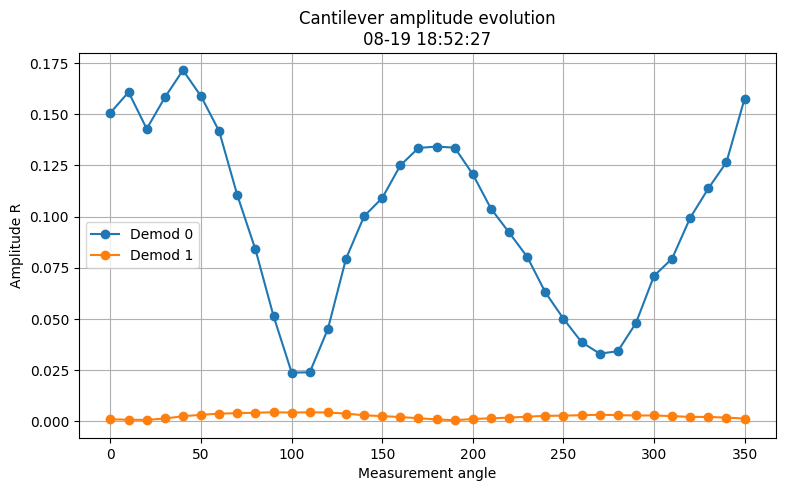

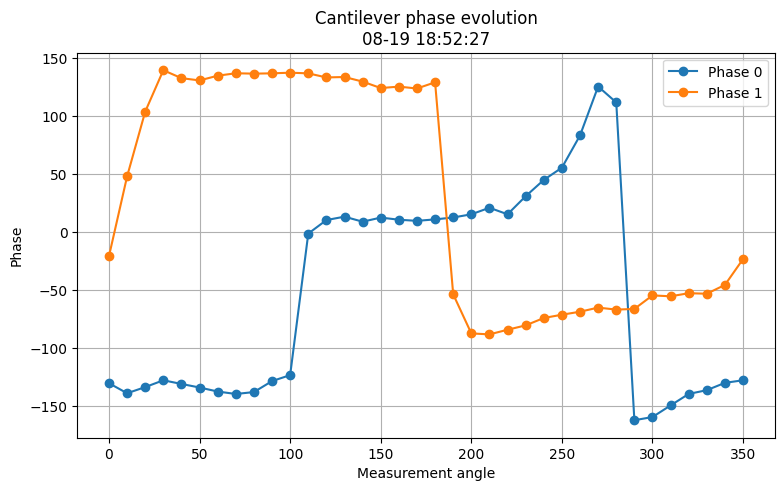

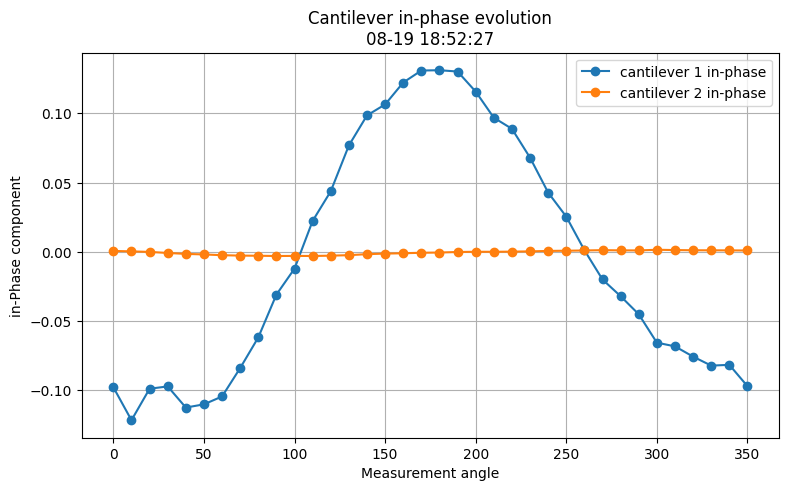

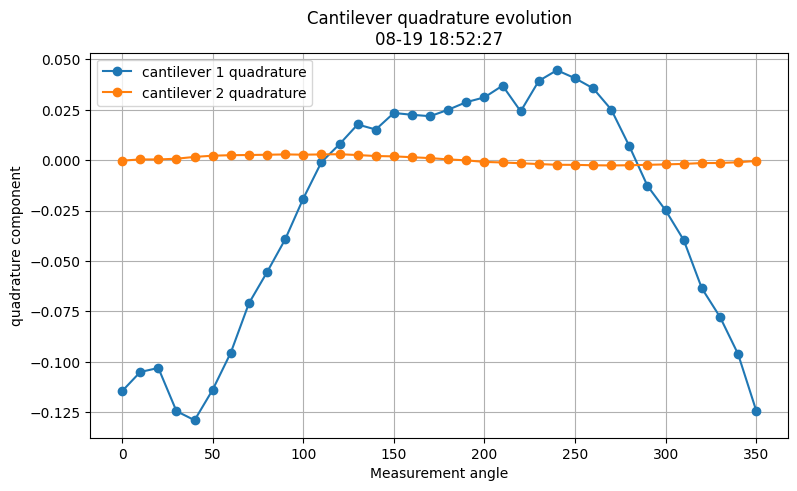

summary and its plottings are done
08-19 19:11:25
71 67 77 89
=-=-=-=-=-=


In [6]:
# new cell for loading calibration files to generate summary //17AUG YZ
import numpy as np
import json
import os

from datetime import datetime
s_timestamp = datetime.now().strftime("%m-%d %H:%M:%S") #timestamp of excution of summary //18AUG YZ

from analysis.measurement_reader import (
    load_measurements,
    summarize_measurements
)
from utils.dataio import save_summary

experiment_folder = r"Data\2026-08-16_11-11-11" # path for calibration, manual input required

print("Reading:")
print(experiment_folder)

measurements = load_measurements( 
    experiment_folder
)

summary = summarize_measurements(
    measurements
)

save_summary(
    summary,
    experiment_folder
)

print(summary)
print(s_timestamp)
####### new cell of summary combined ########

print("Reading:")

print(experiment_folder)

print("fit reading")

fit0_file = os.path.join(
    experiment_folder,
    "fit_demod0.json"
)

fit1_file = os.path.join(
    experiment_folder,
    "fit_demod1.json"
)

with open(fit0_file,"r") as f:

    fit0 = json.load(f)

with open(fit1_file,"r") as f:

    fit1 = json.load(f)

print()
print("Fit demod 0:")
print(fit0)


print()
print("Fit demod 1:")
print(fit1)

# move plot of summary of amplitude and phase here, begins//13AUG YZ
from analysis.plotting import (
    plot_amplitude_summary,
    plot_phase_summary,
    plot_xcomp_summary,
    plot_ycomp_summary    
)

plot_amplitude_summary(
    summary,
    save_path=os.path.join(
        experiment_folder,
        "amplitude_summary.png"
    )
)

plot_phase_summary(
    summary,
    save_path=os.path.join(
        experiment_folder,
        "phase_summary.png"
    )
)

plot_xcomp_summary(
    summary,
    save_path=os.path.join(
        experiment_folder,
        "x_comp.png"
    )
)

plot_ycomp_summary(
    summary,
    save_path=os.path.join(
        experiment_folder,
        "y_comp.png"
    )
)

print("summary and its plottings are done")
print(s_timestamp)
# move plot of summary of amplitude and phase here, ends //13AUG YZ
# save the plot of phase //15AUG YZ
print("71 67 77 89")
print("=-=-=-=-=-=")

In [ ]:
from datetime import datetime
import os

timestamp = datetime.now().strftime("%m-%d %H:%M:%S")
from analysis.calibration import save_calibration
from analysis.calibration import build_calibration_from_csv
from analysis.calibration import load_calibration

from analysis.calibration_plot import plot_calibration
from analysis.calibration_plot import plot_calibration_cantilevers #11AUG YZ
from analysis.calibration_plot import plot_calibration_diff #12AUG YZ
from analysis.calibration_plot import plot_calibration_rmmag
from analysis.calibration_plot import plot_calibration_norm_diff #19AUG YZ



experiment_folder = r"Data\2026-08-16_00-00-00" # input the experiement folder //13AUG YZ

# build the calibration file //13AUG YZ
calibration = build_calibration_from_csv(
   experiment_folder # original = r"Data\2026-08-13_18-14-05", changed to use identified folder
)


save_calibration(
     calibration,
#     #experiment_folder + r"Data\2026-08-13_18-14-05\calibration.npy"
   experiment_folder + r"\calibration_from_summary.npy"
 )

calibration = load_calibration(
     experiment_folder + r"\calibration.npy"
)

# plot_calibration(
#     calibration,
#     save_path=os.path.join(
#             experiment_folder,
#             "ratio_mean_cplx.png")
#     )#plot cantilever 1 / cantilever 2

# plot_calibration_cantilevers(
#     calibration,
#     save_path_CL1 = os.path.join(
#             experiment_folder,
#             "mean_CL1.png"),
#     save_path_CL2 = os.path.join(
#             experiment_folder,
#             "mean_CL2.png")
# )#plot cantilever characteristics from CH1 CH2 //11AUG YZ

# plot_calibration_diff(
#     calibration,
#     save_path=os.path.join(
#         experiment_folder,
#         "diff_mean.png") 
# ) #plot cantilever 1 - cantilever 2

# plot_calibration_rmmag(
#     calibration,
#     save_path=os.path.join(
#         experiment_folder,
#         "ratio_mean_mag.png") #plot Mean(|z0|) / Mean(|z1|) 
# )
plot_calibration_norm_diff(
    calibration,
    save_path=os.path.join(
        experiment_folder,
        "ratio_mean_mag.png") #plot normalized difference (mean(z0)-mean(z1))/(abs(mean(z0))+abs(mean(z1))) //19AUG YZ
)

print("calibration and plots are done")
print(timestamp)


Calibration built from CSV
Source: Data\2026-08-16_00-00-00\summary.csv
Number of angles: 36
{'angles': array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.,
       110., 120., 130., 140., 150., 160., 170., 180., 190., 200., 210.,
       220., 230., 240., 250., 260., 270., 280., 290., 300., 310., 320.,
       330., 340., 350.]), 'Cantilever 1': array([-3.20209982e-02-0.0448794j , -5.66408612e-02-0.02859173j,
       -5.67509780e-02+0.02347297j, -6.75530118e-03+0.0588682j ,
        3.21620823e-02+0.04606704j,  5.67356520e-02+0.01986395j,
        5.23129022e-02-0.01437637j,  3.12358550e-02-0.03307767j,
        1.05871993e-02-0.02949776j, -8.34184876e-05-0.01705528j,
        3.46113332e-03-0.00586192j,  1.06869195e-02-0.01273255j,
        1.61887999e-02-0.02647384j, -5.52690222e-03-0.03206735j,
       -3.00251524e-02-0.03137347j, -4.80966000e-02+0.00751141j,
       -3.83847284e-02+0.03918841j, -1.33640476e-02+0.0567254j ,
        1.22820139e-02+0.05596844j,  4.00282401e

CALIBRATION LOADED
File        = Data\2026-08-12_00-00-00\summary.csv
Points      = 36
Angle range = +0.00° ... +350.00°

First calibration point:
Angle = +0.00°
Z1 = -0.0036643583 +0.0037352324j
Z2 = -0.0016901076 -0.0011954907j
ND = -0.2703443879 +0.6751895082j


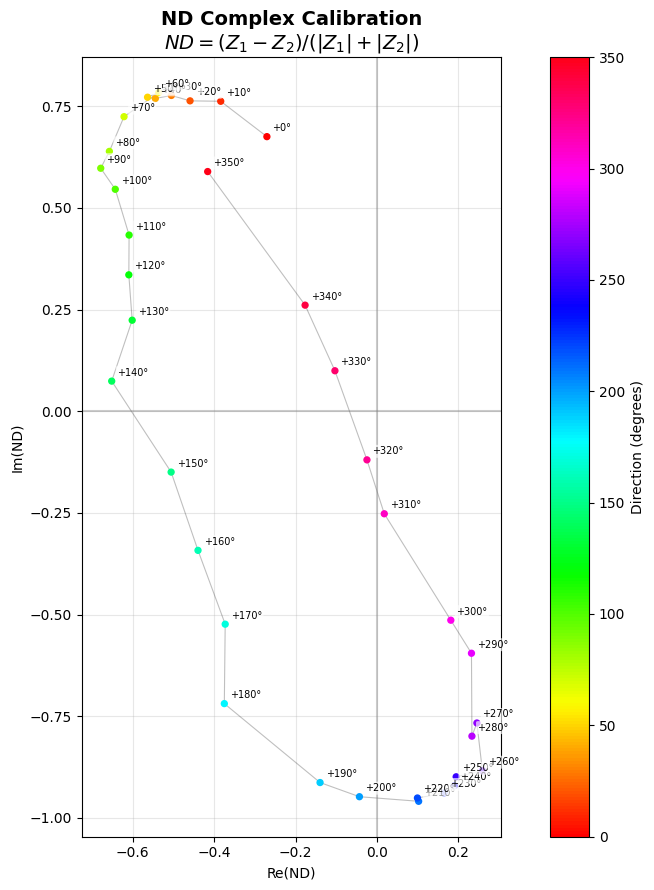

In [3]:
# new cell for calibration and plot //17AUG YZ
# ================================================================

# LOAD summary.csv AND PLOT ND CALIBRATION
#
# CSV structure:
#
# angle,x_0,y_0,x_1,y_1
#
# Z1 = x_0 + j*y_0
# Z2 = x_1 + j*y_1
#
# ND = (Z1-Z2)/(|Z1|+|Z2|)
# ================================================================

import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------
# LOAD CSV
# ------------------------------------------------

filename = r"Data\2026-08-12_00-00-00\summary.csv"

data = np.genfromtxt(
    filename,
    delimiter=",",
    names=True
)


# ------------------------------------------------
# READ COLUMNS
# ------------------------------------------------

angles_cal = np.asarray(
    data["angle"],
    dtype=float
)

Z1_cal = (
    np.asarray(data["x_0"], dtype=float)
    +
    1j * np.asarray(data["y_0"], dtype=float)
)

Z2_cal = (
    np.asarray(data["x_1"], dtype=float)
    +
    1j * np.asarray(data["y_1"], dtype=float)
)


# ------------------------------------------------
# NORMALIZED DIFFERENCE
# ------------------------------------------------

denominator = (
    np.abs(Z1_cal)
    +
    np.abs(Z2_cal)
)

ND_cal = np.full(
    len(angles_cal),
    np.nan + 1j*np.nan,
    dtype=complex
)

valid = denominator > 1e-30

ND_cal[valid] = (
    (Z1_cal[valid] - Z2_cal[valid])
    /
    denominator[valid]
)


# ------------------------------------------------
# PRINT BASIC INFORMATION
# ------------------------------------------------

print("=" * 80)
print("CALIBRATION LOADED")
print("=" * 80)

print(f"File        = {filename}")
print(f"Points      = {len(angles_cal)}")
print(
    f"Angle range = "
    f"{angles_cal.min():+.2f}° ... "
    f"{angles_cal.max():+.2f}°"
)

print()
print("First calibration point:")
print(
    f"Angle = {angles_cal[0]:+.2f}°"
)
print(
    f"Z1 = "
    f"{Z1_cal[0].real:+.10f} "
    f"{Z1_cal[0].imag:+.10f}j"
)
print(
    f"Z2 = "
    f"{Z2_cal[0].real:+.10f} "
    f"{Z2_cal[0].imag:+.10f}j"
)
print(
    f"ND = "
    f"{ND_cal[0].real:+.10f} "
    f"{ND_cal[0].imag:+.10f}j"
)


# ------------------------------------------------
# PLOT
# ------------------------------------------------

fig, ax = plt.subplots(
    figsize=(10, 9)
)

sc = ax.scatter(
    ND_cal.real,
    ND_cal.imag,
    c=angles_cal,
    cmap="hsv",
    s=18,
    zorder=3
)

ax.plot(
    ND_cal.real,
    ND_cal.imag,
    color="black",
    linewidth=0.8,
    alpha=0.25
)


# ------------------------------------------------
# LABEL EVERY 10°
# ------------------------------------------------

for angle in np.arange(0, 360, 10):

    idx = np.argmin(
        np.abs(
            angles_cal - angle
        )
    )

    if np.isfinite(
        ND_cal[idx].real
    ):

        ax.annotate(
            f"{angle:+.0f}°",
            (
                ND_cal[idx].real,
                ND_cal[idx].imag
            ),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=7,
            bbox=dict(
                boxstyle="round,pad=0.15",
                fc="white",
                ec="none",
                alpha=0.65
            )
        )


ax.axhline(
    0,
    color="gray",
    alpha=0.4
)

ax.axvline(
    0,
    color="gray",
    alpha=0.4
)

ax.set_aspect(
    "equal",
    adjustable="box"
)

ax.set_xlabel(
    "Re(ND)"
)

ax.set_ylabel(
    "Im(ND)"
)

ax.set_title(
    "ND Complex Calibration\n"
    r"$ND=(Z_1-Z_2)/(|Z_1|+|Z_2|)$",
    fontsize=14,
    fontweight="bold"
)

ax.grid(alpha=0.3)

plt.colorbar(
    sc,
    ax=ax,
    label="Direction (degrees)"
)

plt.tight_layout()
plt.show()

In [ ]:
# new cell to convert a measurement result to complex vector //17AUG YZ


# ================================================================
# 
# LOAD UNKNOWN MEASUREMENT
#
# File:
#     029_angle_280.npy
#
# ANGLE ESTIMATION:
#     FULL COMPLEX VECTOR ONLY
#
# VISUALIZATION:
#     UNKNOWN ND POINT ON ND CALIBRATION CURVE
# ================================================================

unknown_file = r"Data\2026-08-16_19-36-58\unknow 4.npy"


# ================================================================
# 1. LOAD UNKNOWN
# ================================================================

raw = np.load(
    unknown_file,
    allow_pickle=True
).item()


# ------------------------------------------------
# Read from .npy 
# ------------------------------------------------


Z1_unknown = (
    np.mean(raw["x_0"])
    + 1j *
    np.mean(raw["y_0"])
)

Z2_unknown = (
    np.mean(raw["x_1"])
    + 1j *
    np.mean(raw["y_1"])
)


# ================================================================
# 2. UNKNOWN COMPLEX VECTOR
# ================================================================

V_unknown = np.array(
    [
        Z1_unknown,
        Z2_unknown
    ],
    dtype=complex
)


In [5]:
# new cell the generate a unknown measurement is required //18AUG YZ
# HERE WE RUN unknown_measurement which we want to compare with the calibration!!!

# this cell will generate a new file under the folder of the experiment, the file name is defined by the user input. //07AUG YZ
# the duration of experiment is written in the code with a unit of seconds, and the value is a float. //07AUG YZ


experiment.run(
    duration=2.0
)

Excitation disabled

--------------------------------
Measurement 1

Recording...
Starting measurement
Excitation enabled
Streaming: ['/dev376/demods/0/sample', '/dev376/demods/1/sample']
Demod 0 points: 1800
Demod 1 points: 1790
Synchronizing to 1790 points
Points recorded: 1790
Excitation disabled
Excitation disabled
Recording finished.
DEBUG experiment_angle = 222.0
Saved: Data\2026-08-17_11-02-57\001_angle_222.npy
Excitation disabled

--------------------------------
Measurement 2

Recording...
Starting measurement
Excitation enabled
Streaming: ['/dev376/demods/0/sample', '/dev376/demods/1/sample']
Demod 0 points: 1806
Demod 1 points: 1796
Synchronizing to 1796 points
Points recorded: 1796
Excitation disabled
Excitation disabled
Recording finished.
DEBUG experiment_angle = 101.0
Saved: Data\2026-08-17_11-02-57\002_angle_101.npy
Excitation disabled

--------------------------------
Measurement 3

Experiment finished.



Running minimum residual search...

LEAST-SQUARES MINIMUM RESIDUAL SEARCH
Unknown point X: 0.8900 + j0.0000
Magnitude |X|: 0.8900
Phase arg(X): 0.00°
----------------------------------------------------------------------
Idx #  0 | Angle:    0° | Mag: 0.8078 | |Res|:  0.0822 | Res²: 0.006761
Idx #  1 | Angle:   10° | Mag: 0.8367 | |Res|:  0.0533 | Res²: 0.002839
Idx #  2 | Angle:   20° | Mag: 0.8588 | |Res|:  0.0312 | Res²: 0.000971
Idx #  3 | Angle:   30° | Mag: 0.8832 | |Res|:  0.0068 | Res²: 0.000046
Idx #  4 | Angle:   40° | Mag: 0.9097 | |Res|:  0.0197 | Res²: 0.000389
Idx #  5 | Angle:   50° | Mag: 0.9381 | |Res|:  0.0481 | Res²: 0.002317
Idx #  6 | Angle:   60° | Mag: 0.9560 | |Res|:  0.0660 | Res²: 0.004360
Idx #  7 | Angle:   70° | Mag: 0.9605 | |Res|:  0.0705 | Res²: 0.004966
Idx #  8 | Angle:   80° | Mag: 0.9513 | |Res|:  0.0613 | Res²: 0.003760
Idx #  9 | Angle:   90° | Mag: 0.9351 | |Res|:  0.0451 | Res²: 0.002033
Idx # 10 | Angle:  100° | Mag: 0.9055 | |Res|:  0.0155 | R

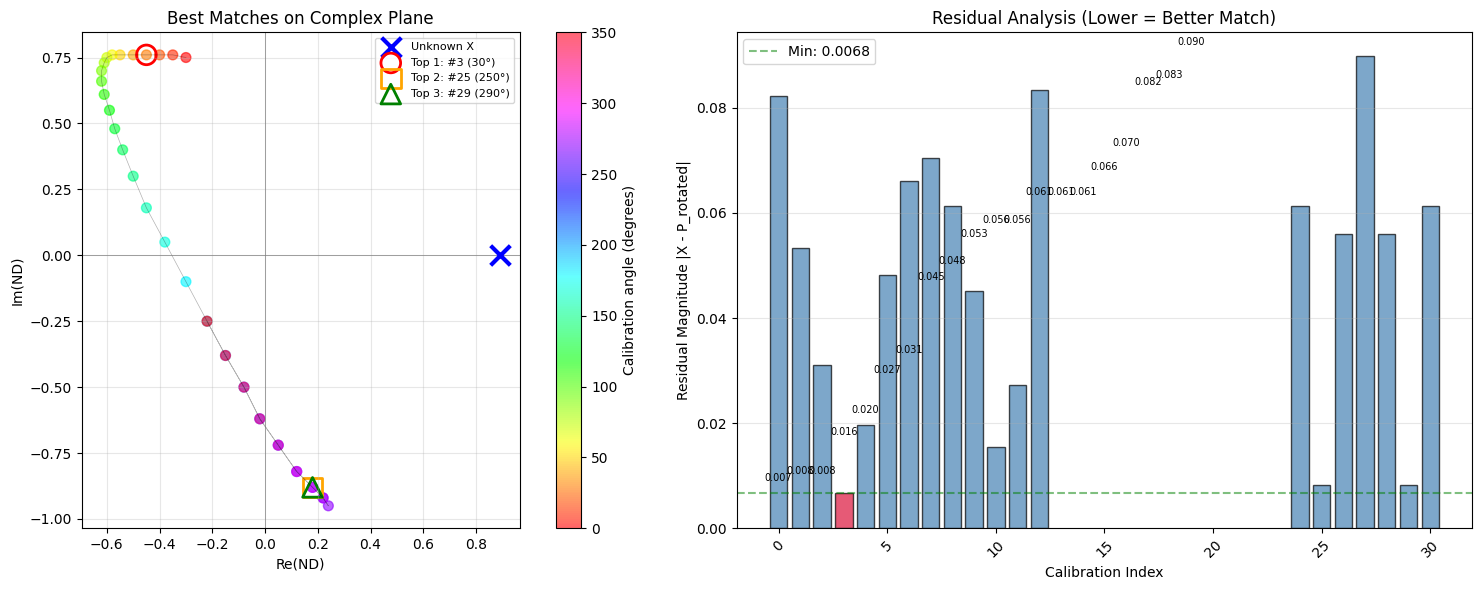


FINAL RECOMMENDATION
Best matching calibration point: Index #3
Labeled angle: 30°
Squared residual: 0.000046
Magnitude match: 0.8832 vs |X|=0.8900
Rotation phase: 239.37°

✓ Excellent match! Residual is very small.


In [2]:
# new cell to estimate the unknown angle //18AUG YZ
import numpy as np
import matplotlib.pyplot as plt

def find_best_calibration_point_least_squares(calibration_data, unknown_point_x):
    """
    Find calibration point using minimum residual criterion:
    min ||w - w_estimate||^2 where w_estimate is the rotated calibration point
    
    The algorithm:
    1. For each calibration point, compute required rotation to align with X
    2. Apply rotation and compute residual error
    3. Return point with minimum squared residual
    
    Parameters:
    - calibration_data: list of tuples (re_nd, im_nd, angle_degrees)
    - unknown_point_x: tuple (re_x, im_x)
    
    Returns:
    - Best match information with residual analysis
    """
    
    # Convert unknown point to complex number
    z_x = complex(unknown_point_x[0], unknown_point_x[1])
    
    results = []
    
    print("=" * 70)
    print("LEAST-SQUARES MINIMUM RESIDUAL SEARCH")
    print("=" * 70)
    print(f"Unknown point X: {z_x.real:.4f} + j{z_x.imag:.4f}")
    print(f"Magnitude |X|: {abs(z_x):.4f}")
    print(f"Phase arg(X): {np.degrees(np.angle(z_x)):.2f}°")
    print("-" * 70)
    
    for idx, (re_cal, im_cal, angle_deg) in enumerate(calibration_data):
        z_cal = complex(re_cal, im_cal)
        mag_cal = abs(z_cal)
        phase_cal = np.angle(z_cal)
        
        # Calculate rotation angle needed to align calibration point with X
        rotation_phase = np.angle(z_x) - phase_cal
        
        # Calculate what the rotated calibration point would be
        # (this should equal X if perfect match)
        z_cal_rotated = z_cal * np.exp(1j * rotation_phase)
        
        # Compute squared residual: ||X - P_cal_rotated||²
        residual_vector = z_x - z_cal_rotated
        residual_magnitude = abs(residual_vector)
        squared_residual = residual_magnitude ** 2
        
        # Also compute magnitude difference (rotation-invariant check)
        magnitude_diff = abs(mag_cal) - abs(z_x)
        squared_mag_diff = magnitude_diff ** 2
        
        results.append({
            'index': idx,
            'angle_deg': angle_deg,
            'calibration_point': z_cal,
            'magnitude': mag_cal,
            'phase_cal': phase_cal,
            'rotation_needed': np.degrees(rotation_phase) % 360,
            'residual_vector': residual_vector,
            'residual_magnitude': residual_magnitude,
            'squared_residual': squared_residual,
            'magnitude_diff': magnitude_diff,
            'squared_mag_diff': squared_mag_diff
        })
        
        print(f"Idx #{idx:3d} | Angle: {angle_deg:4d}° | Mag: {mag_cal:6.4f} | "
              f"|Res|: {residual_magnitude:7.4f} | Res²: {squared_residual:.6f}")
    
    # Sort by squared residual (minimum first)
    results_sorted = sorted(results, key=lambda x: x['squared_residual'])
    
    return results_sorted

def find_by_magnitude_only(calibration_data, unknown_point_x):
    """
    Alternative method: since rotation preserves magnitude,
    simply find calibration point with closest magnitude.
    This is mathematically equivalent to rotation-invariant search.
    """
    
    z_x = complex(unknown_point_x[0], unknown_point_x[1])
    mag_x = abs(z_x)
    
    results = []
    for idx, (re_cal, im_cal, angle_deg) in enumerate(calibration_data):
        z_cal = complex(re_cal, im_cal)
        mag_cal = abs(z_cal)
        
        diff = mag_cal - mag_x
        squared_diff = diff ** 2
        
        results.append({
            'index': idx,
            'angle_deg': angle_deg,
            'magnitude': mag_cal,
            'magnitude_diff': diff,
            'squared_diff': squared_diff
        })
    
    # Sort by squared magnitude difference
    results_sorted = sorted(results, key=lambda x: x['squared_diff'])
    return results_sorted

def visualize_with_residual_analysis(calibration_data, results_sorted, 
                                      unknown_point_x, top_n=3):
    """Plot showing the top matches and residual analysis"""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Plot 1: Complex plane visualization
    ax1 = axes[0]
    
    re_vals = [p[0] for p in calibration_data]
    im_vals = [p[1] for p in calibration_data]
    angles = [p[2] for p in calibration_data]
    
    # Plot calibration curve with color coding
    scatter = ax1.scatter(re_vals, im_vals, c=angles, cmap='hsv', s=50, alpha=0.6)
    ax1.plot(re_vals, im_vals, 'k-', linewidth=0.5, alpha=0.3)
    
    # Mark unknown point X
    x_re, x_im = unknown_point_x
    ax1.scatter([x_re], [x_im], c='blue', marker='x', s=200, linewidths=3, 
               label=f'Unknown X', zorder=5)
    
    # Highlight top N matches
    for i, match in enumerate(results_sorted[:top_n]):
        idx = match['index']
        marker = ['o', 's', '^'][i % 3]
        color = ['red', 'orange', 'green'][i % 3]
        ax1.scatter([re_vals[idx]], [im_vals[idx]], 
                   facecolors='none', edgecolors=color, 
                   s=200, linewidths=2, marker=marker, 
                   label=f'Top {i+1}: #{idx} ({match["angle_deg"]}°)')
    
    ax1.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
    ax1.axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
    ax1.set_xlabel('Re(ND)')
    ax1.set_ylabel('Im(ND)')
    ax1.set_title('Best Matches on Complex Plane')
    ax1.legend(fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.set_aspect('equal')
    
    cbar = plt.colorbar(scatter, ax=ax1)
    cbar.set_label('Calibration angle (degrees)')
    
    # Plot 2: Residual analysis
    ax2 = axes[1]
    
    indices = [m['index'] for m in results_sorted[:20]]
    residuals = [m['residual_magnitude'] for m in results_sorted[:20]]
    angles_list = [m['angle_deg'] for m in results_sorted[:20]]
    
    bars = ax2.bar(indices[:20], residuals[:20], 
                   color='steelblue', alpha=0.7, edgecolor='black')
    
    ax2.set_xlabel('Calibration Index')
    ax2.set_ylabel('Residual Magnitude |X - P_rotated|')
    ax2.set_title('Residual Analysis (Lower = Better Match)')
    ax2.tick_params(axis='x', rotation=45)
    
    # Highlight best match
    best_idx = results_sorted[0]['index']
    for bar, idx in zip(bars, indices[:20]):
        if idx == best_idx:
            bar.set_facecolor('crimson')
    
    ax2.axhline(y=min(residuals), color='green', linestyle='--', 
                alpha=0.5, label=f'Min: {min(residuals):.4f}')
    ax2.legend()
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add residual values as text
    for i, (idx, res) in enumerate(zip(indices[:20], residuals[:20])):
        ax2.text(i, res + max(residuals)*0.02, f'{res:.3f}', 
                ha='center', va='bottom', fontsize=7)
    
    plt.tight_layout()
    plt.savefig('least_squares_result.png', dpi=150, bbox_inches='tight')
    plt.show()

def print_detailed_report(results_sorted, top_n=5):
    """Print detailed comparison report"""
    
    print("\n" + "=" * 70)
    print(f"TOP {top_n} MATCHES BY LEAST-SQUARES CRITERION")
    print("=" * 70)
    
    for i, match in enumerate(results_sorted[:top_n]):
        rank = "BEST MATCH ✓" if i == 0 else f"Rank {i+1}"
        
        print(f"\n{rank}:")
        print(f"  Calibration Index: {match['index']}")
        print(f"  Labeled Angle:     {match['angle_deg']}°")
        print(f"  Magnitude:         {match['magnitude']:.4f}")
        print(f"  Rotation Needed:   {match['rotation_needed']:.2f}°")
        print(f"  Residual Vector:   {match['residual_vector'].real:.4f} + j{match['residual_vector'].imag:.4f}")
        print(f"  Residual |Δ|:      {match['residual_magnitude']:.4f}")
        print(f"  Squared Residual:  {match['squared_residual']:.6f}")
        print(f"  Magnitude Diff:    {match['magnitude_diff']:+.4f}")

# Main execution
if __name__ == "__main__":
    # ==================================================================
    # STEP 1: Populate calibration data (extract from your image)
    # You can extract coordinates manually or use image processing
    # ==================================================================
    calibration_data = [
        # Format: (re_nd, im_nd, angle_degrees)
        # Replace these with actual measurements from your plot
        (-0.30,  0.75,   0),   # +0°
        (-0.35,  0.76,  10),   # +10°
        (-0.40,  0.76,  20),   # +20°
        (-0.45,  0.76,  30),   # +30°
        (-0.50,  0.76,  40),   # +40°
        (-0.55,  0.76,  50),   # +50°
        (-0.58,  0.76,  60),   # +60°
        (-0.60,  0.75,  70),   # +70°
        (-0.61,  0.73,  80),   # +80°
        (-0.62,  0.70,  90),   # +90°
        (-0.62,  0.66, 100),   # +100°
        (-0.61,  0.61, 110),   # +110°
        (-0.59,  0.55, 120),   # +120°
        (-0.57,  0.48, 130),   # +130°
        (-0.54,  0.40, 140),   # +140°
        (-0.50,  0.30, 150),   # +150°
        (-0.45,  0.18, 160),   # +160°
        (-0.38,  0.05, 170),   # +170°
        (-0.30, -0.10, 180),   # +180°
        (-0.22, -0.25, 190),   # +190°
        (-0.15, -0.38, 200),   # +200°
        (-0.08, -0.50, 210),   # +210°
        (-0.02, -0.62, 220),   # +220°
        ( 0.05, -0.72, 230),   # +230°
        ( 0.12, -0.82, 240),   # +240°  <- Note: This is near bottom red circle
        ( 0.18, -0.88, 250),   # +250°
        ( 0.22, -0.92, 260),   # +260°
        ( 0.24, -0.95, 270),   # +270°
        ( 0.22, -0.92, 280),   # +280°
        ( 0.18, -0.88, 290),   # +290°
        ( 0.12, -0.82, 300),   # +300°
        ( 0.05, -0.72, 310),   # +310°
        (-0.02, -0.62, 320),   # +320°
        (-0.08, -0.50, 330),   # +330°
        (-0.15, -0.38, 340),   # +340°
        (-0.22, -0.25, 350),   # +350°
    ]
    
    # ==================================================================
    # STEP 2: Enter your unknown point X coordinates
    # Based on your image, X appears at approximately (0.9, 0.0)
    # Adjust these values based on precise measurement
    # ==================================================================
    unknown_x = (0.89, 0.00)
    
    # ==================================================================
    # STEP 3: Run least-squares search
    # ==================================================================
    print("\nRunning minimum residual search...\n")
    
    # Method A: Full least-squares with rotation
    ls_results = find_best_calibration_point_least_squares(calibration_data, unknown_x)
    
    # Method B: Magnitude-only (rotation-invariant)
    mag_results = find_by_magnitude_only(calibration_data, unknown_x)
    
    # ==================================================================
    # STEP 4: Print detailed report
    # ==================================================================
    print_detailed_report(ls_results, top_n=5)
    
    # ==================================================================
    # STEP 5: Visualize results
    # ==================================================================
    visualize_with_residual_analysis(calibration_data, ls_results, 
                                      unknown_x, top_n=3)
    
    # ==================================================================
    # FINAL RESULT SUMMARY
    # ==================================================================
    best_match = ls_results[0]
    
    print("\n" + "=" * 70)
    print("FINAL RECOMMENDATION")
    print("=" * 70)
    print(f"Best matching calibration point: Index #{best_match['index']}")
    print(f"Labeled angle: {best_match['angle_deg']}°")
    print(f"Squared residual: {best_match['squared_residual']:.6f}")
    print(f"Magnitude match: {best_match['magnitude']:.4f} vs |X|={abs(complex(*unknown_x)):.4f}")
    print(f"Rotation phase: {best_match['rotation_needed']:.2f}°")
    
    if ls_results[0]['squared_residual'] < 0.01:
        print("\n✓ Excellent match! Residual is very small.")
    elif ls_results[0]['squared_residual'] < 0.05:
        print("\n✓ Good match. Residual is acceptable.")
    else:
        print("\n⚠ Warning: Large residual. Consider verifying coordinate measurements.")

In [2]:
from project_summary import summarize_project

summarize_project()



TWO CANTILEVERS LOCK-IN FRAMEWORK

################################################################################
INSTRUMENT
################################################################################

instrument

instrument.hf2li

CLASSES


CLASS: HF2LI
    Driver class for the Zurich Instruments HF2LI.
    __init__(self, device_id, host='localhost', hf2=True)
    _initialize_aux_outputs(self)
    _initialize_demodulators(self)
    _initialize_inputs(self)
    _initialize_oscillators(self)
    _initialize_outputs(self)
    _initialize_pids(self)
    _initialize_plls(self)
    _initialize_scope(self)
    configure_demod(self, demod=0, adc=0, oscillator=0, rate=1000)
    configure_input(self, channel=0, input_range=1.0)
    configure_output(self, channel=0, amplitude=0.01, offset=0.0)
    connect(self)
    disable_excitation(self)
    disconnect(self)
    enable_excitation(self)
    initialize(self)
    read_sample(self, demod=0)
    read_stream(self, demod=0, duration=2.0)
   

In [7]:
from project_summary import build_project_documentation

build_project_documentation()

Reference written to PROJECT_REFERENCE.md
Project tree written to PROJECT_TREE.txt

Project documentation updated.
